In [1]:
#Import Packages
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn import metrics #metrics for diagnostics
from sklearn.metrics import roc_curve,auc,recall_score,precision_score,accuracy_score,f1_score
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
#Print multiple statement in the same line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

In [4]:
##Import file
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#Explore data
df.shape
type(df)
df.size
df.head()
df.tail()


(7043, 21)

pandas.core.frame.DataFrame

147903

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
#Checking for missing values
pd.isnull(df).any()

,0
customerID,False
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False


In [7]:
#Checking for missing values
pd.isnull(df).any()

,0
customerID,False
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False


In [8]:
#Checking the count for missing values
pd.isnull(df).sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
#Find out variable type. Note that object means string or categorical in the below output
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
#Except the below variables all are categorical
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
#Convert Total charges into numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#Missing value imputation
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [12]:
#Convert Total charges into numeric
df['TotalCharges']=pd.to_numeric(df.TotalCharges, errors='coerce')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
#Convert Total charges into numeric
df['TotalCharges']=pd.to_numeric(df.TotalCharges, errors='coerce')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
#frequency of a categorical variable
print('count of Labels')
df.groupby("Churn").size()

count of Labels


,0
Churn,
No,5174
Yes,1869


In [15]:
1869/(1869+5174)

0.2653698707936959

In [16]:
#Convert churn from (yes,No) to (0,1)
le=preprocessing.LabelEncoder()
le.fit(df['Churn'])
list(le.classes_)

LabelEncoder()

['No', 'Yes']

In [17]:

dfn=le.transform(df['Churn'])
le.inverse_transform([0,1])
df['y']=dfn
df.info()
df.columns

array(['No', 'Yes'], dtype=object)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'y'],
      dtype='object')

In [18]:
#Separate out independent categorical variables for conversion into numerical
x_catg=df.loc[:,('gender','Partner', 'Dependents','PhoneService', 'MultipleLines',
                 'InternetService',    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling','PaymentMethod')]


In [19]:
#Display top 5 rows
x_catg.head()
#Display shape
x_catg.shape

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic)
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check


(7043, 15)

In [20]:
#Separate out independent numerical variables
x_num=df.loc[:,('SeniorCitizen','tenure','MonthlyCharges','TotalCharges')]
x_num

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [21]:
# Convert categorical variables into dummy coding
x_num1=pd.get_dummies(x_catg)
x_num1.head()

,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,True,False,False,True,True,False,True,False,False,True,...,False,True,False,False,False,True,False,False,True,False
1,False,True,True,False,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,True
2,False,True,True,False,True,False,False,True,True,False,...,False,True,False,False,False,True,False,False,False,True
3,False,True,True,False,True,False,True,False,False,True,...,False,False,True,False,True,False,True,False,False,False
4,True,False,True,False,True,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False


In [22]:
#get all x's together
x=pd.concat([x_num1,x_num],axis=1)
x.head()

,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,...,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,True,False,False,True,True,False,True,False,False,True,...,False,True,False,False,True,False,0,1,29.85,29.85
1,False,True,True,False,True,False,False,True,True,False,...,True,False,False,False,False,True,0,34,56.95,1889.50
2,False,True,True,False,True,False,False,True,True,False,...,False,True,False,False,False,True,0,2,53.85,108.15
3,False,True,True,False,True,False,True,False,False,True,...,True,False,True,False,False,False,0,45,42.30,1840.75
4,True,False,True,False,True,False,False,True,True,False,...,False,True,False,False,True,False,0,2,70.70,151.65


In [23]:
x.head()

,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,...,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,True,False,False,True,True,False,True,False,False,True,...,False,True,False,False,True,False,0,1,29.85,29.85
1,False,True,True,False,True,False,False,True,True,False,...,True,False,False,False,False,True,0,34,56.95,1889.50
2,False,True,True,False,True,False,False,True,True,False,...,False,True,False,False,False,True,0,2,53.85,108.15
3,False,True,True,False,True,False,True,False,False,True,...,True,False,True,False,False,False,0,45,42.30,1840.75
4,True,False,True,False,True,False,False,True,True,False,...,False,True,False,False,True,False,0,2,70.70,151.65


In [24]:
# Create dep variable
y=df['y']
y.head()

,y
0,0
1,0
2,1
3,0
4,1


In [25]:
#create training and test
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.25,random_state=1)
train_x.shape
train_y.shape
test_x.shape
test_y.shape

(5282, 45)

(5282,)

(1761, 45)

(1761,)

In [26]:
train_x.isnull().sum()

,0
gender_Female,0
gender_Male,0
Partner_No,0
Partner_Yes,0
Dependents_No,0
Dependents_Yes,0
PhoneService_No,0
PhoneService_Yes,0
MultipleLines_No,0
MultipleLines_No phone service,0


In [27]:
#Logistic Regression model
from sklearn.linear_model import LogisticRegression
log=LogisticRegression(max_iter=50000)

In [28]:
train_x.isnull().sum()

,0
gender_Female,0
gender_Male,0
Partner_No,0
Partner_Yes,0
Dependents_No,0
Dependents_Yes,0
PhoneService_No,0
PhoneService_Yes,0
MultipleLines_No,0
MultipleLines_No phone service,0


In [29]:
#Fit a model
log.fit(train_x,train_y)

LogisticRegression(max_iter=50000)

In [30]:
#
log.coef_


array([[-6.86376350e-02, -7.24247829e-02, -9.18214721e-02,
        -4.92409458e-02, -3.44683060e-02, -1.06594112e-01,
         7.45679630e-02, -2.15630381e-01, -2.33322881e-01,
         7.45679630e-02,  1.76925006e-02, -3.56653413e-01,
         3.31453333e-01, -1.15862337e-01,  1.96347724e-01,
        -1.15862337e-01, -2.21547804e-01,  8.24596348e-02,
        -1.15862337e-01, -1.07659715e-01,  4.35254103e-02,
        -1.15862337e-01, -6.87254909e-02,  1.72881312e-01,
        -1.15862337e-01, -1.98081393e-01, -8.80726784e-02,
        -1.15862337e-01,  6.28725978e-02, -1.20526062e-01,
        -1.15862337e-01,  9.53259818e-02,  5.88035859e-01,
        -3.42781493e-03, -7.25670462e-01, -2.28692725e-01,
         8.76303071e-02, -8.19865823e-02, -1.27603304e-01,
         2.02006009e-01, -1.33478541e-01,  2.19470338e-01,
        -6.19676384e-02,  2.53918344e-03,  3.30825883e-04]])

In [31]:
#Find out the key predictor of churn
coeff=pd.concat([pd.DataFrame(x.columns),pd.DataFrame(np.transpose(log.coef_))],axis=1)
coeff.columns=("Variable","Coeff")
coeff.sort_values=("variable","ascending=True")

In [32]:
#
coeff


,Variable,Coeff
0,gender_Female,-0.068638
1,gender_Male,-0.072425
2,Partner_No,-0.091821
3,Partner_Yes,-0.049241
4,Dependents_No,-0.034468
5,Dependents_Yes,-0.106594
6,PhoneService_No,0.074568
7,PhoneService_Yes,-0.215630
8,MultipleLines_No,-0.233323
9,MultipleLines_No phone service,0.074568


In [33]:
#Generate Model Diagnostics
classes=log.predict(test_x)
classes

array([0, 0, 0, ..., 0, 1, 0])

In [34]:
print(classes.size)

1761


In [35]:
print('Positive cases in Test data:', test_y[test_y == 1].shape[0])

Positive cases in Test data: 434


In [36]:
print('Negative cases in Test data:', test_y[test_y == 0].shape[0])

Negative cases in Test data: 1327


In [37]:
#Explore data
df.shape
type(df)
df.size
df.head()
df.tail()

(7043, 22)

pandas.core.frame.DataFrame

154946

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,y
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,y
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,0


In [38]:
#Generate Model Diagnostics
classes=log.predict(test_x)
print(classes.size)
print('Positive cases in Test data:', test_y[test_y == 1].shape[0])
print('Negative cases in Test data:', test_y[test_y == 0].shape[0])
#Precision and Recall
print('Accuracy Score')
print(metrics.accuracy_score(test_y,classes))
print('Precision/Recall Metrics')
print(metrics.classification_report(test_y,classes))
print('AUC')
auc=metrics.roc_auc_score(test_y,classes)
auc


1761
Positive cases in Test data: 434
Negative cases in Test data: 1327
Accuracy Score
0.8120386144236229
Precision/Recall Metrics
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1327
           1       0.63      0.57      0.60       434

    accuracy                           0.81      1761
   macro avg       0.75      0.73      0.74      1761
weighted avg       0.81      0.81      0.81      1761

AUC


np.float64(0.7303044877916648)

Confusion Matrix


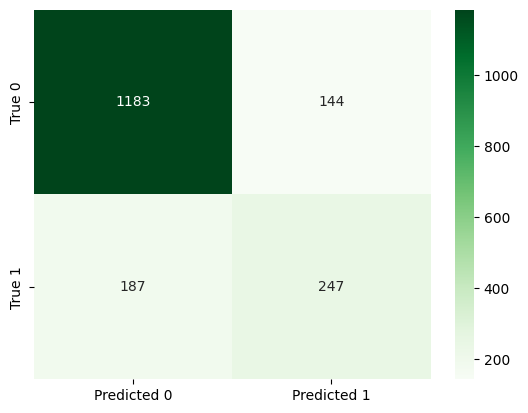

In [39]:
print('Confusion Matrix')
cf=metrics.confusion_matrix(test_y,classes)
lbl1=["Predicted 0","Predicted 1"]
lbl2=["True 0","True 1"]
sns.heatmap(cf,annot=True,cmap="Greens",fmt="d",xticklabels=lbl1,yticklabels=lbl2)
plt.show();

In [40]:
(1189+241)/(1189+139+193+241)

0.811577752553916

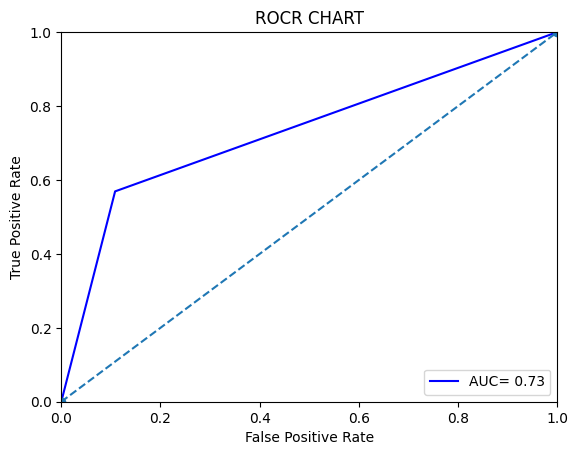

In [41]:
#ROC Chart
fpr,tpr,th=roc_curve(test_y,classes)
roc_auc=metrics.auc(fpr,tpr)
import matplotlib.pyplot as plt
plt.title('ROCR CHART')
plt.plot(fpr,tpr,'b', label='AUC= %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'o--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();
#


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

# 1. Decision Tree
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(train_x, train_y)

# 2. Support Vector Machine
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(train_x, train_y)

# 3. Neural Network (simple MLP)
nn = MLPClassifier(hidden_layer_sizes=(32,16), activation='relu',
                   solver='adam', max_iter=500, random_state=42)
nn.fit(train_x, train_y)

# 4. AdaBoost
ada = AdaBoostClassifier(n_estimators=3, random_state=42)
ada.fit(train_x, train_y)

# 5. Random Forest
rf = RandomForestClassifier(n_estimators=3, max_depth=2, random_state=42)
rf.fit(train_x, train_y)


In [ ]:

from sklearn.metrics import classification_report, accuracy_score

models = {'Decision Tree': dtree,
          'SVM': svm,
          'Neural Net': nn,
          'AdaBoost': ada,
          'Random Forest': rf}

for name, model in models.items():
    preds = model.predict(test_x)
    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy_score(test_y, preds)*100,2), "%")
    print(classification_report(test_y, preds))
